In [1]:
print('hello')

hello


In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [3]:
# -----------------------------
# Parameters
# -----------------------------
params = {
    # Calcium flux parameters
    "k_PMCA": 0.4,      # Wang extrusion rate 
    "V_Pmax": 4.5,      # Wang PMCA pump max rate 
    "V_s": 4.5,         # Wang/Lytton SR uptake rate max for SERCA pump between 0.1 and 0.5
    "k_s": 0.1,         # Wang/Lytton SR uptake affinity for SERCA pump between 0.1 and 0.5 
    "k_leak": 0.1,      # Wang SR leak
    "F": 96485.3329,    # Physical Faraday's constant 

    "P": 1.0, # IP3 production proxy by agonist 


    "g_Ca": 9.0,        # Wang nS mM^-1 
    "V_m": -50.0,       # Wang mV 
    "k_m": 12.0,        # Wang mV 
    "R": 8314,         # Physical mJ/(mol K)
    "T": 310.0,          # Wang K (37°C) 

    "a_0": 0.05, # Wang
    "a_1": 0.25, # Wang
    "a_2": 1, # Wang

    "k_1": 2000, # Wang,. DeY 
    "k_-1": 260, # Wang, DeY
    "K_1": 0.13, # Wang, DeY - derived 
    "k_2": 1, # Wang, DeY
    "k_-2": 1.05, # Wang, DeY
    "K_2": 1.05, # Wang, DeY - derived
    "k_3": 2000, # Wang, DeY
    "k_-3": 1886, # Wang, DeY
    "K_3": 0.943, # Wang, DeY - derived
    "k_4": 1, # Wang, DeY
    "k_-4": 0.145, # Wang, DeY
    "K_4": 0.145, # Wang, DeY - derived
    "k_5": 100, # Wang, DeY
    "k_-5": 8.2, # Wang, DeY
    "K_5": 0.082, # Wang, DeY - derived

    # Channel gains
    "k_IP3R": 5.55, #Wang
    "k_RyR": 5.0, #Wang 
    "k_ryr0": 0.0072, # Wang and Friel RyR opening rate
    "k_ryr1": 0.334, # Wang and Friel and Shannon RyR closing rate
    "k_ryr2": 0.5, # Wang and Friel and Shannon RyR activation affinity
    "k_ryr3": 38.0, # Wang and Shannon RyR inactivation affinity

    # Voltage parameters
    "c_m": 1.0, # Lata
    "I_stim": 0.1175, # Lata

    # Contraction
    "alpha": 3.0, #Lata - uterine
    "beta": 0.001, #Lata - uterine
    "n_F": 4, # Lata - uterine

    # Functional parameters
    "n": 4, # Wang - Hill coefficient for SERCA channel activation 1, 2 or 4
    "ns": 2, # Wang and Lytton
    "n2": 3 # Wang 3 or 5 
}

In [4]:
# -----------------------------
# Flux definitions
# -----------------------------
# def J_in(Ca_0, Ca_in, p):
#     return p["k_in"] * (Ca_0 - Ca_in)

def J_in_Wang(V, Ca_in, Ca_0, p):
    return p["a_0"]-p["a_1"]*I_Ca(V, Ca_in, Ca_0, p)/(2*p["F"]) +p["a_2"]*p["P"]  

def m_inf(V, p):
    return 1.0 / (1.0 + np.exp(-(V - p["V_m"]) / p["k_m"]))

def V_Ca(V, Ca_in, Ca_0, p):
    F = p["F"]
    R = p["R"]
    T = p["T"]

    exp_term = np.exp(-2.0 * V * F / (R * T))

    denom = 1.0 - exp_term
    if np.abs(denom) < 1e-8:
        return 1e-8

    return V * (Ca_in - Ca_0 * exp_term) / denom

def I_Ca(V, Ca_in, Ca_0, p):
    m = m_inf(V, p)
    Vca = V_Ca(V, Ca_in, Ca_0, p)
    return p["g_Ca"] * (m**2) * Vca

def J_PMCA(Ca_0, Ca_in, p):
    return p["k_PMCA"] * (Ca_in - Ca_0)

def J_PMCA_Hill(Ca_in, p):
    return p["V_Pmax"] * (Ca_in**p["n"]) / (p["k_PMCA"]**p["n"] + Ca_in**p["n"]) # - Ca_0**p["n"]

def J_SERCA(Ca_0, Ca_in, p):
    return p["V_s"] * (Ca_in - Ca_0)

def J_SERCA_Hill(Ca_in, p):
    return p["V_s"] * (Ca_in**p["ns"]) / (p["k_s"]**p["ns"] + Ca_in**p["ns"]) # - Ca_0**p["n"]

def J_leak(Ca_SR, Ca_in, p):
    return p["k_leak"] * (Ca_SR - Ca_in)

def J_IP3R(Ca_SR, Ca_in, p):
    return p["k_IP3R"] * (Ca_SR - Ca_in)

def J_IP3R_Wang(Ca_SR, Ca_in, y_g, p):
    return p["k_IP3R"] * P_IP3R(Ca_in, y_g, p) * (Ca_SR - Ca_in)

def P_IP3R(Ca_in, y, p):
    return (p["P"] * Ca_in*(1.0 - y) / ((p["P"] + p["K_1"]) * (Ca_in + p["K_5"])))**p["n2"]

def dy_dt(y, p, Ca_in):
    f1 = (p["k_4"] * p["K_2"] * p["K_1"] + p["k_2"] * p["K_4"] * p["P"]) * Ca_in / (p["K_4"] * p["K_2"] * (p["K_1"] + p["P"]))
    f2 = (p["k_2"] * p["P"] + p["k_4"] * p["K_3"]) / (p["K_3"] + p["P"])
    return f1 * (1.0 - y) - f2 * y

def J_RyR_Hill(Ca_SR, Ca_in, p):
    return p["k_RyR"] * (Ca_SR**p["n"]/(p["K_RyR"]**p["n"]+Ca_SR**p["n"])) * (Ca_SR - Ca_in)

def J_RyR_Wang(Ca_SR, Ca_in, p):
    return p["k_RyR"] * P_RyR(Ca_in, Ca_SR, p) * (Ca_SR - Ca_in)

def P_RyR(Ca_in, Ca_SR, p):
    # CICR activation term (cytosolic Ca)
    activation = (
        p["k_ryr0"]
        + (p["k_ryr1"] * Ca_in**3) / (p["k_ryr2"]**3 + Ca_in**3)
    )

    # SR load dependence
    sr_term = Ca_SR**4 / (p["k_ryr3"]**4 + Ca_SR**4)

    return activation * sr_term

In [5]:
# -----------------------------
# ODE system
# -----------------------------
def model(t, state, p):
    Ca_0, Ca_in, Ca_SR, V, y_g = state

    # Fluxes
    Jin = J_in_Wang(V, Ca_in, Ca_0, p)
    JPMCA = J_PMCA_Hill(Ca_in, p)
    JSERCA = J_SERCA_Hill(Ca_in, p)

    dyg_dt = dy_dt(y_g, p, Ca_in)

    Jip3r = J_IP3R_Wang(Ca_SR, Ca_in, y_g, p)
    Jryr = J_RyR_Wang(Ca_SR, Ca_in, p)
    Jleak = J_leak(Ca_SR, Ca_in, p)

    # Calcium dynamics
    dCa0_dt = JPMCA - Jin
    dCain_dt = Jin - JPMCA - JSERCA + Jip3r + Jryr + Jleak
    dCaSR_dt = JSERCA - Jip3r - Jryr - Jleak

    # Membrane voltage (simple RC model)
    dV_dt =  1/p["c_m"]*(p["I_stim"] + Ca_0 - Ca_in) 

    return [dCa0_dt, dCain_dt, dCaSR_dt, dV_dt, dyg_dt]

In [6]:
# -----------------------------
# Contraction function
# -----------------------------
def contraction(Ca_in, p):
    return p["alpha"] * Ca_in**p["n_F"] / (p["beta"]**p["n_F"] + Ca_in**p["n_F"])

In [7]:
# -----------------------------
# Simulation
# -----------------------------
y0 = [0, 0.112, 24, -60, 0]  # initial conditions for Ca_0, Ca_in, Ca_SR, V, y_g Wang 

t_span = (0, 20)
t_eval = np.linspace(*t_span, 1000)

sol = solve_ivp(model, t_span, y0, args=(params,), t_eval=t_eval, method='BDF')

# Extract variables
Ca_0 = sol.y[0]
Ca_in = sol.y[1]
Ca_SR = sol.y[2]
V = sol.y[3]

F = contraction(Ca_in, params)

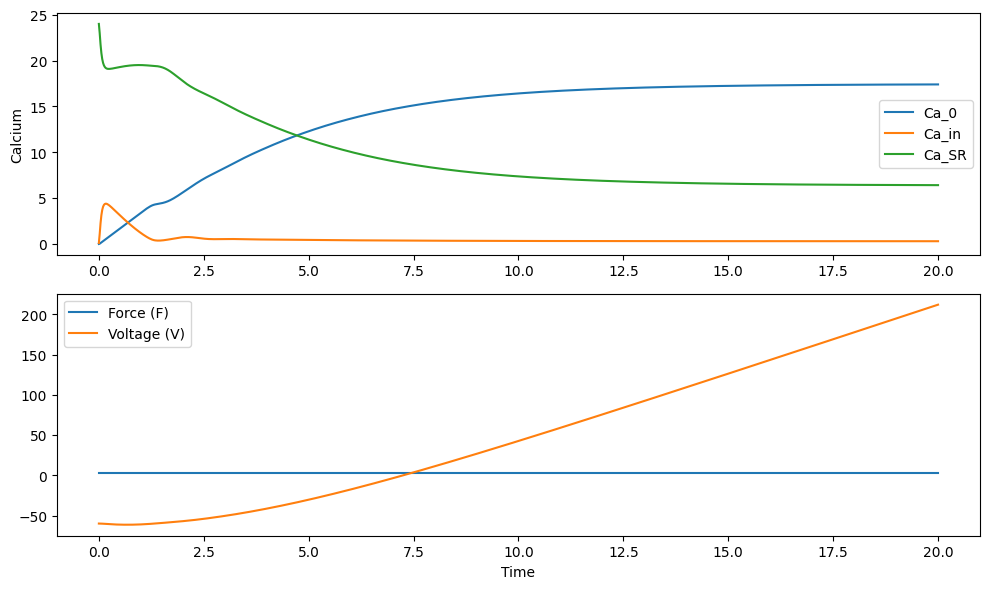

In [8]:
# -----------------------------
# Plotting
# -----------------------------
plt.figure(figsize=(10, 6))

plt.subplot(2,1,1)
plt.plot(sol.t, Ca_0, label="Ca_0")
plt.plot(sol.t, Ca_in, label="Ca_in")
plt.plot(sol.t, Ca_SR, label="Ca_SR")
plt.ylabel("Calcium")
plt.legend()

plt.subplot(2,1,2)
plt.plot(sol.t, F, label="Force (F)")
plt.plot(sol.t, V, label="Voltage (V)")
plt.xlabel("Time")
plt.legend()

plt.tight_layout()
plt.show()